# Interpretable Multi-Omics Ovarian Cancer Survival Prediction

This notebook trains and interprets an L1-regularized Logistic Regression ensemble for ovarian cancer survival classification using three processed omics layers: DNA methylation, mRNA-seq, and copy-number alteration (CNA).

**Important data note:** The input datasets used in this notebook have already been cleaned and processed before model training. Missing values have been handled, patient/sample identifiers have been structured, the dataset structurisation/structuring has been completed, and the omics matrices have been organized into model-ready tabular formats. This notebook therefore starts from processed `.pkl` files and focuses on feature selection, model training, ensemble prediction, and explainability.

The final reported metrics in this notebook are the metrics generated by the code in this run. These should be treated as the current model results rather than older values shown elsewhere.

## 1. Library imports

This cell imports the core Python libraries used for data handling, model training, evaluation, feature selection, visualization, and SHAP-based explainability. The workflow mainly uses `pandas` and `numpy` for data manipulation, scikit-learn for modeling, and SHAP for local feature explanations.

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,balanced_accuracy_score
from sklearn.model_selection import train_test_split,GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict
import shap
genelist=[
    "CDH1", "STK16", "MAL", "GJB1", "TESK1", "PTH2R", "DNAJC9", "SRI", "WWP1", "AKT1S1",
    "MYOD1", "NF1", "CPNE1", "BNIP3L", "NUCB2", "AADAC", "MITF", "CEACAM5", "GMNN", "ATP5A1",
    "C19orf12", "BRCA2", "GMPR", "SMARCA4", "PCDH9", "MAK", "PCK2", "GFRA1", "BAALC", "RNASEL",
    "B4GALT5", "MYC", "LPAR3", "DUSP4", "CDKN3", "E2F6", "FAM58A", "PARP4", "KRT6", "FOXJ1",
    "HSP90AA1", "USP8", "HIF1A", "SMO", "CTLA4", "CCNE1", "ASRGL1", "FGFR1", "IL22", "PPP2R4",
    "ZFHX4", "SPTLC2", "PD.1", "FOXP3", "RB1", "CXCL10", "PAX2", "OPA1", "EZR", "OASL",
    "RARRES1", "ANXA4", "HBB", "SERPINE1", "MINPP1", "APPL2", "MRPS27", "MDM2", "CDK6", "CRABP2",
    "SHPRH", "WDR91", "NTRK2", "GUSB", "OR1G1", "TAP1", "ESR2", "IGHM", "CX3CR1", "MRE11A",
    "VCAN", "GTF2H5", "MEST", "IGF2", "KDM5D", "TCF7L1", "VSIG4", "NF2", "FOXRED2", "MAP2K4",
    "ADH1B", "TBX2", "NUAK2", "ESD", "FGF1", "ZNHIT2", "PGRA", "KLHL7", "SOX17", "TSHR", "CXCL9",

    "TP53",
    "BRCA1",
    "PTEN",
    "KRAS",
    "PIK3CA",
    "MUC16",   
    "WFDC2",   
    "AFP",     
    "CEA",     
    "CGB",     
    "ARID1A",
    "HNF1B",
    "FOXL2",
    "WT1"]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Experiment configuration

The main experiment settings are defined here. The survival threshold is set to 42 months, and fixed random states are used to keep the train/test split and model training reproducible. The variance and top-gene percentage values control the feature-filtering steps used before training the omics-specific models.

In [2]:
month = 42
variance_percentage=0.25
top_gene_percentage=0.1
training_split_percentage=0.75
random_state=3582140361
model_random_state=42
#51024

## 3. Helper functions

This section groups the reusable functions used throughout the notebook. The functions cover feature plotting, dictionary aggregation, feature filtering, model tuning, ensemble voting, and SHAP-based explanation extraction.

The `plot_features()` function is used only for display. It filters repeated explanation features by a minimum frequency threshold and can show results as a table, barplot, or both. The `combine_dicts()` function combines multiple feature-frequency dictionaries so that repeated genes/features across omics layers can be summarized together.

In [3]:
def plot_features(feature_dict, min_frequency=5, heading="Most Common Features", display_type="barplot"):
    """
    Display feature-frequency results as either a table, barplot, or both.

    Parameters:
        feature_dict: dict
            Dictionary mapping feature names to frequency counts.

        min_frequency: int
            Minimum frequency required for a feature to be shown.

        heading: str
            Title for the displayed table or plot.

        display_type: str
            Choose one of:
            - "table"
            - "barplot"
            - "both"

    Returns:
        pd.DataFrame
            Filtered feature-frequency table.
    """

    filtered_dict = {
        feature: count
        for feature, count in feature_dict.items()
        if count >= min_frequency
    }

    df_features = pd.DataFrame(
        list(filtered_dict.items()),
        columns=["Feature", "Frequency"]
    )

    if df_features.empty:
        print(f"No features found with frequency >= {min_frequency}")
        return df_features

    df_features = (
        df_features
        .sort_values("Frequency", ascending=False)
        .reset_index(drop=True)
    )

    if display_type not in ["table", "barplot", "both"]:
        raise ValueError("display_type must be 'table', 'barplot', or 'both'")

    if display_type in ["table", "both"]:
        print(heading)
        display(df_features)

    if display_type in ["barplot", "both"]:
        plt.figure(figsize=(14, max(6, 0.35 * len(df_features))))

        sns.barplot(
            x="Frequency",
            y="Feature",
            data=df_features,
            hue="Feature",
            palette="viridis",
            legend=False
        )

        plt.title(heading)
        plt.xlabel("Frequency")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

    return df_features

def combine_dicts(dict_list):
    """
    Combine multiple feature-frequency dictionaries into one dictionary.

    Parameters:
        dict_list: list of dict
            A list where each dictionary maps feature names to frequency counts.

    Returns:
        dict
            Combined dictionary with summed feature frequencies.
    """
    combined_dict = {}

    for feature_dict in dict_list:
        for feature, count in feature_dict.items():
            combined_dict[feature] = combined_dict.get(feature, 0) + count

    return combined_dict


def get_lr_and_scaled_X(model, X):

    if isinstance(model, Pipeline):
        scaler = model.named_steps["scaler"]
        lr_model = model.named_steps["lr"]
        X_scaled = scaler.transform(X)
    else:
        lr_model = model
        X_scaled = X.values if hasattr(X, "values") else X

    feature_names = list(X.columns) if hasattr(X, "columns") else None

    return lr_model, X_scaled, feature_names


def map_cpg_to_gene(cpg, cpg_to_gene_map):
    mapped = cpg_to_gene_map.get(str(cpg), cpg)

    if isinstance(mapped, list):
        return [str(x) for x in mapped]
    else:
        return [str(mapped)]


def explain_all_samples(
    methyl_model, mrnaseq_model, cna_model,
    methyl_X_test, mrnaseq_X_test, cna_X_test,
    methyl_y_pred, mrnaseq_y_pred, cna_y_pred,
    cpg_to_gene_map,
    top_n=5
):

    aggregated_explanations = {
        "methylation": {},
        "mrnaseq": {},
        "cna": {}
    }

    aggregated_common = {}

    # --------------------------
    # Prepare models + scaled data
    # --------------------------
    methyl_lr, methyl_X_scaled, methyl_feature_names = get_lr_and_scaled_X(
        methyl_model, methyl_X_test
    )

    mrna_lr, mrna_X_scaled, mrna_feature_names = get_lr_and_scaled_X(
        mrnaseq_model, mrnaseq_X_test
    )

    cna_lr, cna_X_scaled, cna_feature_names = get_lr_and_scaled_X(
        cna_model, cna_X_test
    )

    # --------------------------
    # Build SHAP explainers ONCE
    # --------------------------
    methyl_explainer = shap.LinearExplainer(methyl_lr, methyl_X_scaled)
    mrna_explainer = shap.LinearExplainer(mrna_lr, mrna_X_scaled)
    cna_explainer = shap.LinearExplainer(cna_lr, cna_X_scaled)

    # --------------------------
    # Compute SHAP values ONCE
    # --------------------------
    methyl_shap_values = methyl_explainer.shap_values(methyl_X_scaled)
    mrna_shap_values = mrna_explainer.shap_values(mrna_X_scaled)
    cna_shap_values = cna_explainer.shap_values(cna_X_scaled)

    # If SHAP returns list, use positive-class SHAP values
    if isinstance(methyl_shap_values, list):
        methyl_shap_values = methyl_shap_values[1]

    if isinstance(mrna_shap_values, list):
        mrna_shap_values = mrna_shap_values[1]

    if isinstance(cna_shap_values, list):
        cna_shap_values = cna_shap_values[1]

    n_samples = len(methyl_y_pred)

    for i in range(n_samples):

        votes = [
            methyl_y_pred[i],
            mrnaseq_y_pred[i],
            cna_y_pred[i]
        ]

        majority_label = np.bincount(votes).argmax()

        sample_explanations = {}

        # --------------------------
        # Methylation
        # --------------------------
        if methyl_y_pred[i] == majority_label:
            shap_vals = methyl_shap_values[i]

            top_indices = np.argsort(np.abs(shap_vals))[::-1][:top_n]
            top_cpgs = [methyl_feature_names[j] for j in top_indices]

            top_genes = []
            for cpg in top_cpgs:
                top_genes.extend(map_cpg_to_gene(cpg, cpg_to_gene_map))

            sample_explanations["methylation"] = top_genes

            for gene in top_genes:
                aggregated_explanations["methylation"][gene] = (
                    aggregated_explanations["methylation"].get(gene, 0) + 1
                )

        # --------------------------
        # mRNAseq
        # --------------------------
        if mrnaseq_y_pred[i] == majority_label:
            shap_vals = mrna_shap_values[i]

            top_indices = np.argsort(np.abs(shap_vals))[::-1][:top_n]
            top_genes = [str(mrna_feature_names[j]) for j in top_indices]

            sample_explanations["mrnaseq"] = top_genes

            for gene in top_genes:
                aggregated_explanations["mrnaseq"][gene] = (
                    aggregated_explanations["mrnaseq"].get(gene, 0) + 1
                )

        # --------------------------
        # CNA
        # --------------------------
        if cna_y_pred[i] == majority_label:
            shap_vals = cna_shap_values[i]

            top_indices = np.argsort(np.abs(shap_vals))[::-1][:top_n]
            top_genes = [str(cna_feature_names[j]) for j in top_indices]

            sample_explanations["cna"] = top_genes

            for gene in top_genes:
                aggregated_explanations["cna"][gene] = (
                    aggregated_explanations["cna"].get(gene, 0) + 1
                )

        # --------------------------
        # Common genes across agreeing models
        # --------------------------
        if len(sample_explanations) > 1:
            keys = list(sample_explanations.keys())

            common_features = set(sample_explanations[keys[0]])

            for key in keys[1:]:
                common_features = common_features.intersection(
                    set(sample_explanations[key])
                )

            if common_features:
                aggregated_common[i] = list(common_features)


    return aggregated_explanations, aggregated_common

def majority_vote(predictions):
    return np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=1, arr=predictions)


def filter_cpg_sites(cpg_to_gene_map, genelist):
    relevant_cpg_sites = [
        cpg for cpg, genes in cpg_to_gene_map.items() if any(gene in genelist for gene in genes)
    ]
    return relevant_cpg_sites


def feature_splitter(data):
    return(data.iloc[:, :-1],data.iloc[:, -1])

# Function to plot confusion matrix with evaluation metrics
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    # Extracting required metrics
    accuracy = report["accuracy"]
    precision = report["1"]["precision"] if "1" in report else report["0"]["precision"]
    recall = report["1"]["recall"] if "1" in report else report["0"]["recall"]
    f1_score = report["1"]["f1-score"] if "1" in report else report["0"]["f1-score"]

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Actual No', 'Actual Yes'], ax=ax)
    plt.xlabel('Predicted Labels')
    plt.ylabel('Actual Labels')
    plt.title(f'Confusion Matrix - {model_name} Model')

    # Display classification metrics
    plt.figtext(0.5, -0.15, f"Accuracy: {accuracy:.4f}", ha="center", fontsize=12, color='blue')
    plt.figtext(0.5, -0.20, f"Precision: {precision:.4f}", ha="center", fontsize=12, color='red')
    plt.figtext(0.5, -0.25, f"Recall: {recall:.4f}", ha="center", fontsize=12, color='green')
    plt.figtext(0.5, -0.30, f"F1-Score: {f1_score:.4f}", ha="center", fontsize=12, color='black')

    plt.show()
def select_genes(df, variance_percentage=0.25, top_gene_percentage=0.01):
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # Step 1: remove low-variance genes
    var_scores = X.var()
    threshold = var_scores.quantile(variance_percentage)
    X_filtered = X.loc[:, var_scores > threshold]

    # Step 2: keep top correlated genes
    corr_scores = X_filtered.apply(lambda col: abs(col.corr(y)))
    sorted_features = corr_scores.sort_values(ascending=False)

    k = int(np.ceil(top_gene_percentage * X_filtered.shape[1]))
    top_features = sorted_features.index[:k]

    return list(top_features)

## 4. Load processed omics datasets

The processed DNA methylation, mRNA-seq, CNA, and clinical/survival label files are loaded here. The methylation probe-to-gene mapping is also created so that CpG-level methylation features can be interpreted at the gene level when possible.

This notebook assumes that the raw data cleaning, missing-value handling, and structural formatting have already been completed before these files are loaded.

In [4]:
methylation_path = "/Users/shakshamshubham/Desktop/Final year project test/Working file/Datafiles Final/methylation.pkl"

# Load the methylation data
df_methylation = pd.read_pickle(methylation_path)

# Create a hashmap (dictionary) where first row = keys (CpG sites) and second row = values (Genes)
cpg_to_gene_map = {
    cpg: genes.split(';') if isinstance(genes, str) else []  # Handle NaN in genes
    for cpg, genes in zip(df_methylation.iloc[0], df_methylation.iloc[1])
    if isinstance(cpg, str)  # Skip NaN CpG sites
}

gene_to_cpg_map = defaultdict(list)

for cpg, genes in cpg_to_gene_map.items():
    for gene in genes:
        gene_to_cpg_map[gene].append(cpg)  # Each gene points to a list of CpG sites

# Convert defaultdict to normal dict
gene_to_cpg_map = dict(gene_to_cpg_map)

# ===== Define File Paths =====
base_path = "/Users/shakshamshubham/Desktop/Final year project test/Working file/Model code"

# Define the file paths
cna_path = f"{base_path}/{month} month/log2cna_preprocessed.pkl"
methylation_path = f"{base_path}/{month} month/methylation_preprocessed.pkl"
mrnaseq_path = f"{base_path}/{month} month/mrnaseq_preprocessed.pkl"

# Load datasets
df_cna = pd.read_pickle(cna_path)
df_methyl = pd.read_pickle(methylation_path)
df_mrnaseq = pd.read_pickle(mrnaseq_path)

## 5. Match common patients and create train/test split

Only patients available across all three omics layers are used for the final multi-omics workflow. The common patient IDs are identified, then the data is split into train and test sets using the fixed random state defined earlier. This keeps the patient split reproducible across runs.

In [5]:
# Get common samples
p1 = list(df_cna.index)
p2 = list(df_methyl.index)
p3 = list(df_mrnaseq.index)
res = sorted(set(p1) & set(p2) & set(p3)) # Common sample IDs
genelist_methyl = set()

split_count = round(len(res) * (1-training_split_percentage))
print(split_count)

# Randomly select 80 samples for the test set
np.random.seed(random_state)  # Ensure reproducibility
test_samples = np.random.choice(res, size=split_count, replace=False)

# Split into train and test sets based on selected samples
df_cna_test = df_cna.loc[test_samples]
df_methyl_test = df_methyl.loc[test_samples]
df_mrnaseq_test = df_mrnaseq.loc[test_samples]

# Drop the test samples from the original dataset to create the training set
df_cna_train = df_cna.drop(index=test_samples)
df_methyl_train = df_methyl.drop(index=test_samples)
df_mrnaseq_train = df_mrnaseq.drop(index=test_samples)


# Get CpG sites corresponding to the genelist
cpgs_from_genelist = set()
for gene in genelist:
    if gene in gene_to_cpg_map:
        cpgs_from_genelist.update(gene_to_cpg_map[gene])

# Apply feature selection to each training set with genelist
genelist_cna = sorted(set(select_genes(df_cna_train,variance_percentage,top_gene_percentage)).union(set(genelist)))
genelist_mrnaseq = sorted(set(select_genes(df_mrnaseq_train,variance_percentage,top_gene_percentage)).union(set(genelist)))
cpgsite_methyl = sorted(set(select_genes(df_methyl_train, variance_percentage,top_gene_percentage)).union(cpgs_from_genelist))
for cpg in cpgsite_methyl:
    genes = cpg_to_gene_map.get(cpg)
    if genes:
        # If genes is a string of comma-separated gene names, split and clean
        if isinstance(genes, str):
            gene_names = [g.strip() for g in genes.split(',')]
            genelist_methyl.update(gene_names)
        elif isinstance(genes, list) or isinstance(genes, set):
            genelist_methyl.update(genes)
        else:
            genelist_methyl.add(genes)

# Optional: convert to sorted list
genelist_methyl = sorted(genelist_methyl)

53


## 6. Separate targets and filter features

The survival class label is separated from each omics matrix, leaving only molecular features for training. Low-variance features are removed, and the remaining features are filtered further using correlation-based ranking and literature-informed gene add-back. This reduces the high-dimensional omics matrices before Logistic Regression training.

In [6]:
# Extract the target variable before filtering features
y_cna_train = df_cna_train.iloc[:, -1]
y_cna_test = df_cna_test.iloc[:, -1]

y_mrnaseq_train = df_mrnaseq_train.iloc[:, -1]
y_mrnaseq_test = df_mrnaseq_test.iloc[:, -1]

y_methyl_train = df_methyl_train.iloc[:, -1]
y_methyl_test = df_methyl_test.iloc[:, -1]

# === Filter CNA ===
df_cna_train = df_cna_train.loc[:, df_cna_train.columns.isin(genelist_cna)]
df_cna_test = df_cna_test.loc[:, df_cna_test.columns.isin(genelist_cna)]

# Re-add target
df_cna_train["Prediction"] = y_cna_train
df_cna_test["Prediction"] = y_cna_test

# === Filter mRNAseq ===
df_mrnaseq_train = df_mrnaseq_train.loc[:, df_mrnaseq_train.columns.isin(genelist_mrnaseq)]
df_mrnaseq_test = df_mrnaseq_test.loc[:, df_mrnaseq_test.columns.isin(genelist_mrnaseq)]

# Re-add target
df_mrnaseq_train["Prediction"] = y_mrnaseq_train
df_mrnaseq_test["Prediction"] = y_mrnaseq_test

# === Filter Methylation ===
relevant_cpg_sites = filter_cpg_sites(cpg_to_gene_map, genelist_methyl)

df_methyl_train = df_methyl_train.loc[:, df_methyl_train.columns.isin(relevant_cpg_sites)]
df_methyl_test = df_methyl_test.loc[:, df_methyl_test.columns.isin(relevant_cpg_sites)]

# Re-add target
df_methyl_train["Prediction"] = y_methyl_train
df_methyl_test["Prediction"] = y_methyl_test

print("Filtered CNA, Methylation, and mRNAseq datasets using respective genelists while retaining the Prediction column.")


Filtered CNA, Methylation, and mRNAseq datasets using respective genelists while retaining the Prediction column.


## 7. Logistic Regression tuning function

This helper function builds a standardized Logistic Regression pipeline. Features are standardized first, then an L1-regularized Logistic Regression model is tuned using cross-validation. Balanced accuracy is used for tuning because the survival classes are close but not perfectly identical in size.

In [7]:
# --------------------------
# Helper: tune Logistic Regression
# --------------------------
def tune_lr_model(X_train, y_train, name):


    print(f"\n==============================")
    print(f"Starting tuning for {name}")
    print(f"==============================")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            solver="saga",
            random_state=model_random_state,
            max_iter=2000,
            tol=1e-3
        ))
    ])

    param_grid = {
        "lr__l1_ratio": [0, 0.3, 0.7, 1],
        "lr__C": [0.001, 0.01, 0.1, 1, 10],
        "lr__class_weight": [None, "balanced"]
    }

    total_fits = (
        len(param_grid["lr__l1_ratio"]) *
        len(param_grid["lr__C"]) *
        len(param_grid["lr__class_weight"]) *
        3
    )

    print(f"{name}: Total fits = {total_fits}")

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=model_random_state
    )

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    print(f"\nFinished tuning {name}")
    print(f"{name} Best Params:")
    print(grid.best_params_)
    print(f"{name} Best CV Balanced Accuracy: {grid.best_score_:.4f}")

    return grid.best_estimator_, grid.best_score_

# --------------------------
# Helper: evaluate model
# --------------------------
def evaluate_model(model, X_test, y_test, name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    print(f"\n{name} Test Accuracy: {acc:.4f}")
    print(f"{name} Test Balanced Accuracy: {bal_acc:.4f}")
    print(classification_report(y_test, y_pred))

    plot_confusion_matrix(y_test, y_pred, f"{name} Tuned LR")

    return y_pred, y_prob, acc, bal_acc

## 8. Train individual omics models and weighted ensemble

Separate L1 Logistic Regression models are trained for CNA, methylation, and mRNA-seq. Each model is evaluated independently on the test set.

After the individual models are trained, their predicted probabilities are combined using a probability-weighted ensemble. The weights are based on each model's cross-validation balanced accuracy, so models with stronger validation performance contribute slightly more to the final ensemble prediction.


Starting tuning for CNA
CNA: Total fits = 120

Finished tuning CNA
CNA Best Params:
{'lr__C': 0.001, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0}
CNA Best CV Balanced Accuracy: 0.6730

CNA Test Accuracy: 0.7170
CNA Test Balanced Accuracy: 0.7165
              precision    recall  f1-score   support

           0       0.72      0.69      0.71        26
           1       0.71      0.74      0.73        27

    accuracy                           0.72        53
   macro avg       0.72      0.72      0.72        53
weighted avg       0.72      0.72      0.72        53



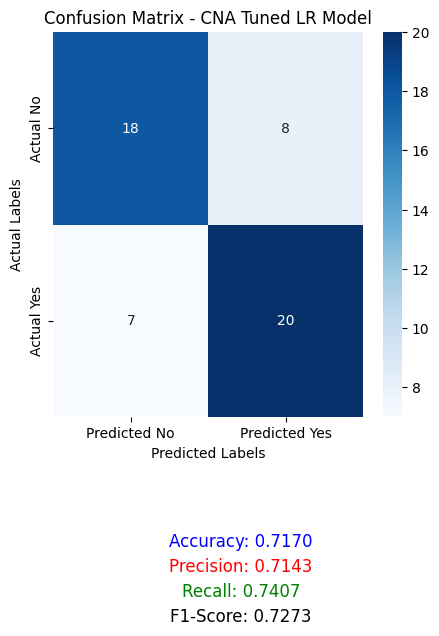


Starting tuning for Methylation
Methylation: Total fits = 120

Finished tuning Methylation
Methylation Best Params:
{'lr__C': 10, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.3}
Methylation Best CV Balanced Accuracy: 0.7598

Methylation Test Accuracy: 0.6604
Methylation Test Balanced Accuracy: 0.6603
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        26
           1       0.67      0.67      0.67        27

    accuracy                           0.66        53
   macro avg       0.66      0.66      0.66        53
weighted avg       0.66      0.66      0.66        53



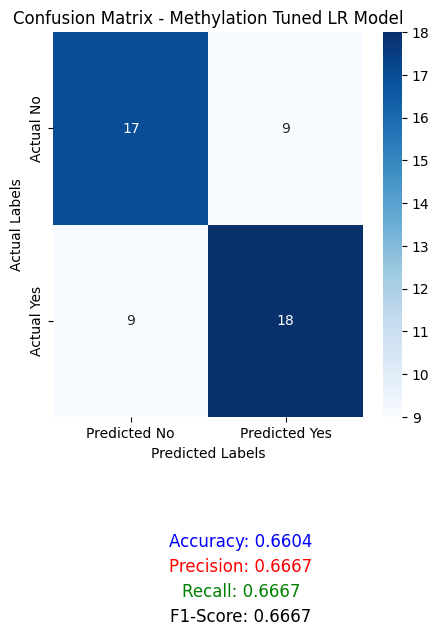


Starting tuning for mRNAseq
mRNAseq: Total fits = 120

Finished tuning mRNAseq
mRNAseq Best Params:
{'lr__C': 0.001, 'lr__class_weight': None, 'lr__l1_ratio': 0}
mRNAseq Best CV Balanced Accuracy: 0.7817

mRNAseq Test Accuracy: 0.6415
mRNAseq Test Balanced Accuracy: 0.6403
              precision    recall  f1-score   support

           0       0.65      0.58      0.61        26
           1       0.63      0.70      0.67        27

    accuracy                           0.64        53
   macro avg       0.64      0.64      0.64        53
weighted avg       0.64      0.64      0.64        53



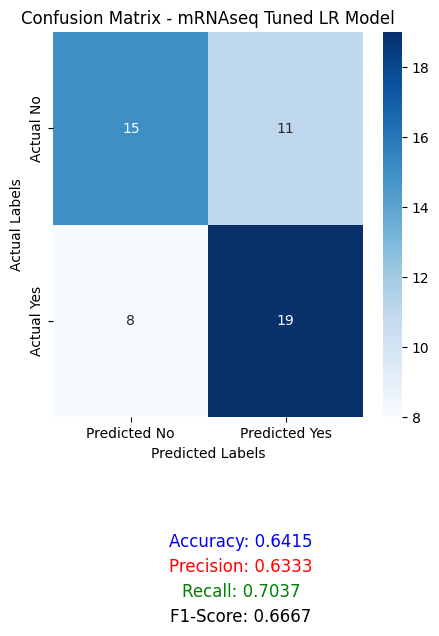


Ensemble Weights:
CNA: 0.3039
Methylation: 0.3431
mRNAseq: 0.3530

Ensemble Test Accuracy: 0.7547
Ensemble Test Balanced Accuracy: 0.7543
              precision    recall  f1-score   support

           0       0.76      0.73      0.75        26
           1       0.75      0.78      0.76        27

    accuracy                           0.75        53
   macro avg       0.76      0.75      0.75        53
weighted avg       0.75      0.75      0.75        53



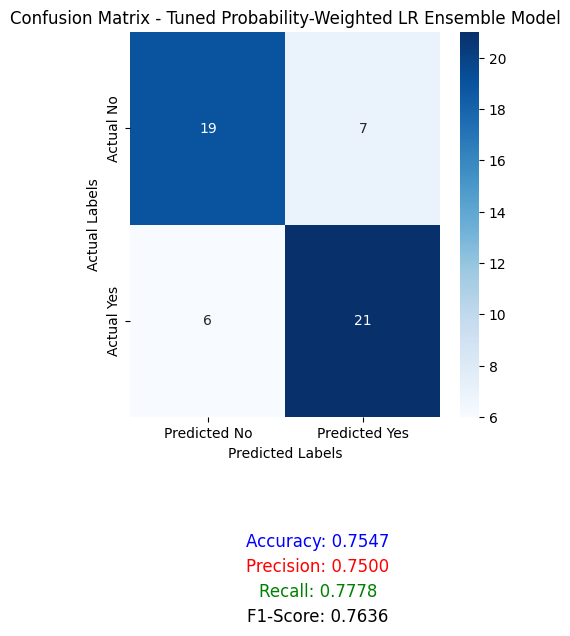

In [8]:
# --------------------------
# CNA
# --------------------------
cna_X_train, cna_y_train = feature_splitter(df_cna_train)
cna_X_test, cna_y_test = feature_splitter(df_cna_test)

cna_best_model, cna_cv_score = tune_lr_model(
    cna_X_train,
    cna_y_train,
    "CNA"
)

cna_y_pred, cna_y_prob, cna_acc, cna_bal_acc = evaluate_model(
    cna_best_model,
    cna_X_test,
    cna_y_test,
    "CNA"
)


# --------------------------
# Methylation
# --------------------------
methyl_X_train, methyl_y_train = feature_splitter(df_methyl_train)
methyl_X_test, methyl_y_test = feature_splitter(df_methyl_test)

methyl_best_model, methyl_cv_score = tune_lr_model(
    methyl_X_train,
    methyl_y_train,
    "Methylation"
)

methyl_y_pred, methyl_y_prob, methyl_acc, methyl_bal_acc = evaluate_model(
    methyl_best_model,
    methyl_X_test,
    methyl_y_test,
    "Methylation"
)


# --------------------------
# mRNAseq
# --------------------------
mrnaseq_X_train, mrnaseq_y_train = feature_splitter(df_mrnaseq_train)
mrnaseq_X_test, mrnaseq_y_test = feature_splitter(df_mrnaseq_test)

mrnaseq_best_model, mrnaseq_cv_score = tune_lr_model(
    mrnaseq_X_train,
    mrnaseq_y_train,
    "mRNAseq"
)

mrnaseq_y_pred, mrnaseq_y_prob, mrnaseq_acc, mrnaseq_bal_acc = evaluate_model(
    mrnaseq_best_model,
    mrnaseq_X_test,
    mrnaseq_y_test,
    "mRNAseq"
)


# --------------------------
# Check labels align before ensemble
# --------------------------
assert np.array_equal(cna_y_test, methyl_y_test), "CNA and methylation test labels do not align."
assert np.array_equal(cna_y_test, mrnaseq_y_test), "CNA and mRNAseq test labels do not align."


# --------------------------
# Ensemble using CV-balanced-accuracy weights
# --------------------------
total_cv_score = cna_cv_score + methyl_cv_score + mrnaseq_cv_score

weights = np.array([
    cna_cv_score / total_cv_score,
    methyl_cv_score / total_cv_score,
    mrnaseq_cv_score / total_cv_score
])

print("\nEnsemble Weights:")
print(f"CNA: {weights[0]:.4f}")
print(f"Methylation: {weights[1]:.4f}")
print(f"mRNAseq: {weights[2]:.4f}")

all_probs = np.vstack([
    cna_y_prob,
    methyl_y_prob,
    mrnaseq_y_prob
]).T

weighted_probs = np.dot(all_probs, weights)

final_predictions = (weighted_probs >= 0.5).astype(int)

ensemble_acc = accuracy_score(cna_y_test, final_predictions)
ensemble_bal_acc = balanced_accuracy_score(cna_y_test, final_predictions)



print(f"\nEnsemble Test Accuracy: {ensemble_acc:.4f}")
print(f"Ensemble Test Balanced Accuracy: {ensemble_bal_acc:.4f}")
print(classification_report(cna_y_test, final_predictions))

plot_confusion_matrix(
    cna_y_test,
    final_predictions,
    "Tuned Probability-Weighted LR Ensemble"
)

## 9. Model results from this run

These are the metrics produced by the code in this notebook and should be treated as the current project results.

| Model | Test Accuracy | Test Balanced Accuracy | Notes |
|---|---:|---:|---|
| CNA | 0.7170 | 0.7165 | Best CV balanced accuracy: 0.6730 |
| Methylation | 0.6604 | 0.6603 | Best CV balanced accuracy: 0.7598 |
| mRNA-seq | 0.6415 | 0.6403 | Best CV balanced accuracy: 0.7817 |
| Probability-weighted ensemble | 0.7547 | 0.7543 | Weights: CNA 0.3039, methylation 0.3431, mRNA-seq 0.3530 |

### Model performance summary

The probability-weighted ensemble produced the strongest test performance in this run, with a test accuracy of **0.7547** and balanced accuracy of **0.7543**. This was higher than the individual CNA, methylation, and mRNA-seq models.

Among the individual models, CNA produced the strongest test performance, while methylation and mRNA-seq had stronger cross-validation balanced accuracy during tuning. The final ensemble uses this difference by combining predictions at the probability level instead of selecting only one omics layer.

## 10. Generate sample-level and aggregated SHAP explanations

The explainability step uses SHAP values from the trained Logistic Regression models to identify features that repeatedly contributed to sample-level predictions. For each test sample, the top contributing features are extracted from models that agree with the sample-level majority prediction.

The repeated features are then aggregated across samples for each omics layer. The frequency shown later in the plots represents how often a gene or feature appeared among the top local explanations. These counts should be interpreted as recurring model explanation signals, not as causal biological conclusions.

In [14]:

aggregated_explanations, aggregated_common = explain_all_samples(
    methyl_model=methyl_best_model,
    mrnaseq_model=mrnaseq_best_model,
    cna_model=cna_best_model,
    methyl_X_test=methyl_X_test,
    mrnaseq_X_test=mrnaseq_X_test,
    cna_X_test=cna_X_test,
    methyl_y_pred=methyl_y_pred,
    mrnaseq_y_pred=mrnaseq_y_pred,
    cna_y_pred=cna_y_pred,
    cpg_to_gene_map=cpg_to_gene_map,
    top_n=5
)

## 11. Methylation explanation features

This plot summarizes CpG-mapped genes that repeatedly appeared in the top SHAP explanations for the methylation model. In this run, **RAD54B** was the most recurrent methylation-linked feature, followed by **C10orf4** and **KLK10**.

The methylation results suggest that the model's explanations were spread across a recurring group of DNA-methylation-linked features rather than being dominated by a single gene. Some of these features, such as **RAD54B**, **IGF2**, and **KLK10**, have clearer ovarian-cancer relevance through DNA repair, imprinting/growth-factor biology, or methylation/prognostic literature. Others should be treated as exploratory methylation-derived signals.

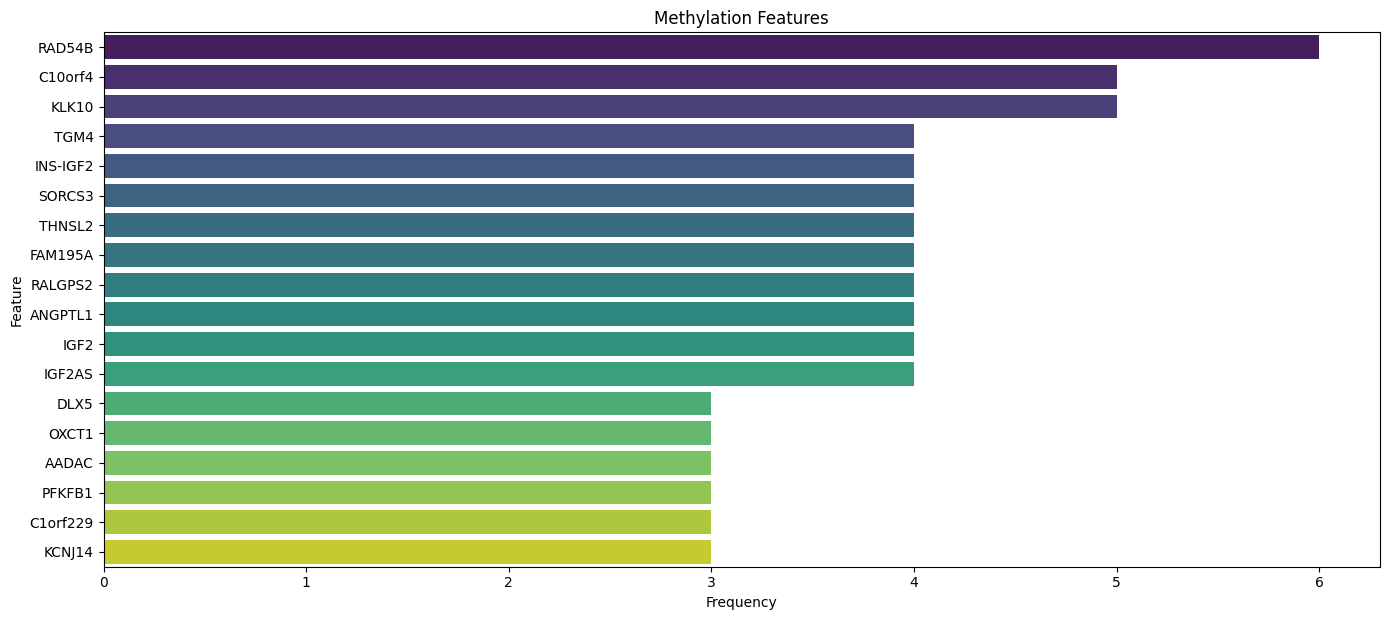

In [10]:
methylation_features = plot_features(
    aggregated_explanations["methylation"],
    min_frequency=3,
    heading="Methylation Features",
    display_type="barplot")


## 12. mRNA-seq explanation features

The mRNA-seq explanation plot shows a more concentrated pattern. **CCL14** was the dominant recurring transcriptomic feature, appearing far more frequently than the other mRNA-seq features in this run.

This pattern suggests that the mRNA-seq model's local explanations were strongly concentrated around CCL14. Since CCL14 is a chemokine and has been reported as a prognostic factor in epithelial ovarian cancer, its recurrence is biologically plausible for a survival-classification task. The other transcriptomic features shown here appeared less frequently and should be interpreted more cautiously.

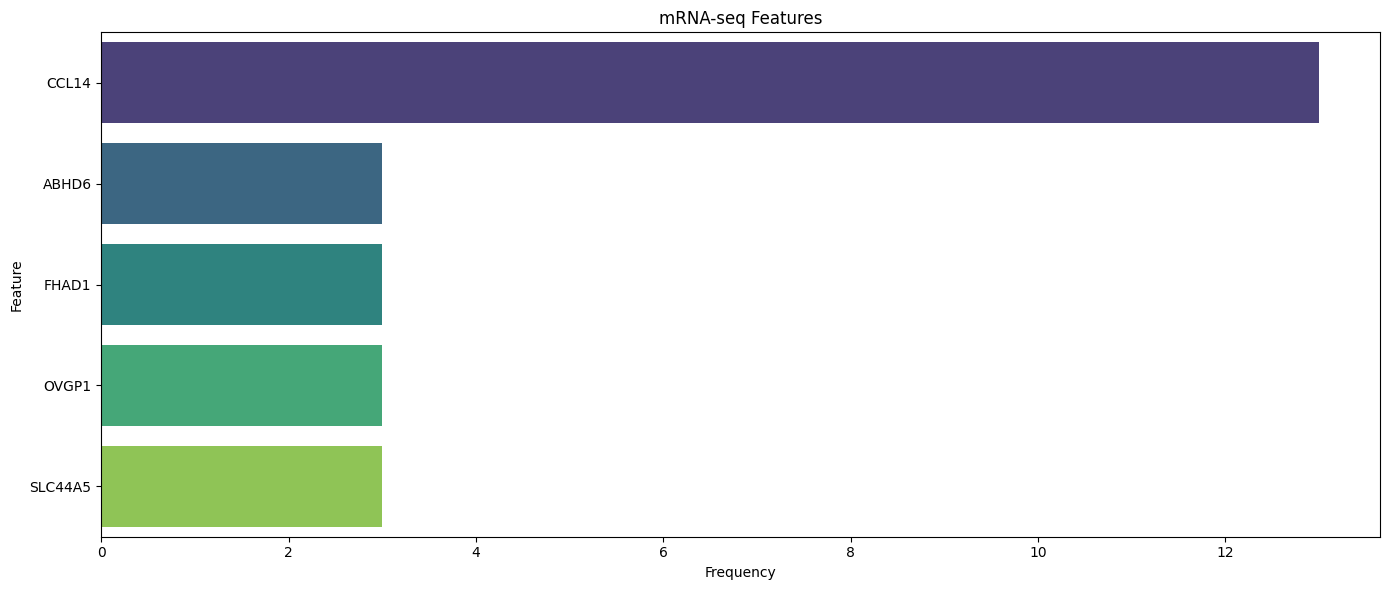

In [11]:

mrnaseq_features = plot_features(
    aggregated_explanations["mrnaseq"],
    min_frequency=3,
    heading="mRNA-seq Features",
    display_type="barplot"
)

## 13. CNA explanation features

The CNA explanation plot shows the strongest and broadest recurrence pattern among the individual omics layers. **FRMD5** appeared most frequently, followed by **LRRN1**, **ATP5A1**, and **RIPPLY2**.

Several additional CNA features, including **NUAK2**, **AADAC**, **CAT**, **FOXJ1**, **NF1**, **GUSB**, **RFT1**, and **MRAP2**, also appeared repeatedly. This suggests that copy-number variation contributed a strong recurrent explanatory signal across multiple test samples.

CNA features should be interpreted carefully because a copy-number signal can represent dosage changes across genomic regions, not necessarily direct gene-expression activity. Still, many of the repeated CNA features align with ovarian-cancer-relevant themes such as copy-number alteration, DNA repair/RAS signaling, mitochondrial metabolism, oxidative stress response, and tumor progression.

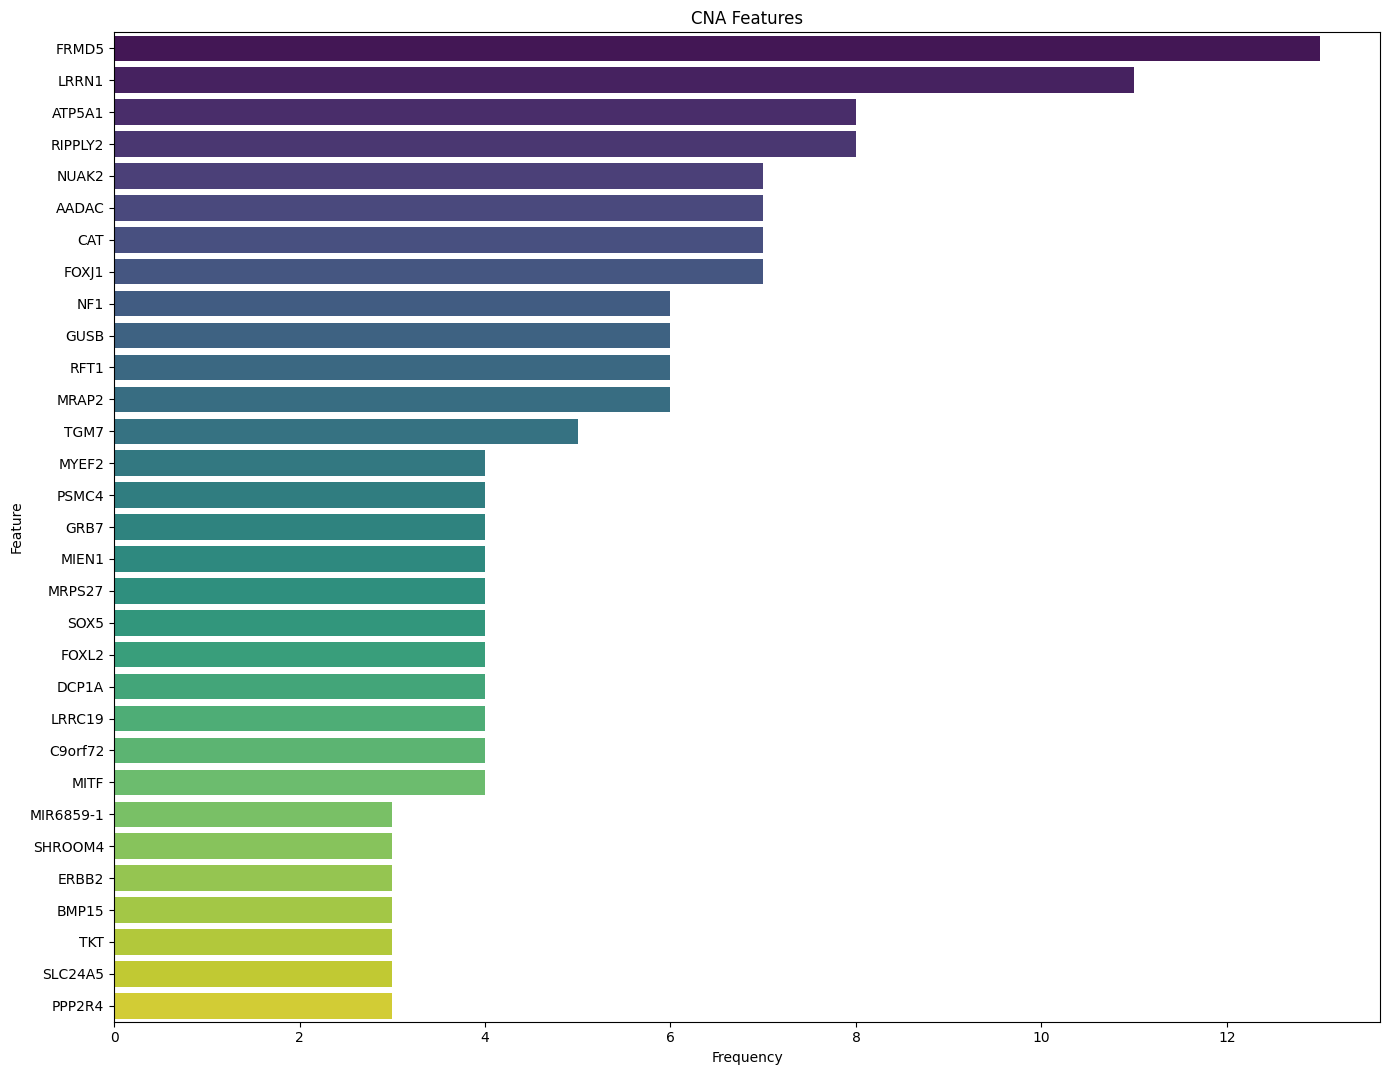

In [12]:
cna_features = plot_features(
    aggregated_explanations["cna"],
    min_frequency=3,
    heading="CNA Features",
    display_type="barplot"
)

## 14. Combined repeated features across all omics layers

The combined feature plot adds together recurrence counts from the methylation, mRNA-seq, and CNA explanation dictionaries. A feature appearing in this plot does not necessarily mean it appeared in every omics layer. It means the total recurrence count across the selected dictionaries reached the minimum frequency threshold.

Using a minimum frequency of 5, the strongest combined features were **FRMD5** and **CCL14**, each appearing 13 times. **LRRN1** followed with 11 appearances, while **AADAC** reached 10 appearances after combining counts across layers. **RIPPLY2** and **ATP5A1** appeared 8 times each, and **NUAK2**, **FOXJ1**, **RAD54B**, and **CAT** also remained among the most recurrent combined features.

These combined results provide a compact view of the most repeated model explanation signals across the full multi-omics ensemble workflow.

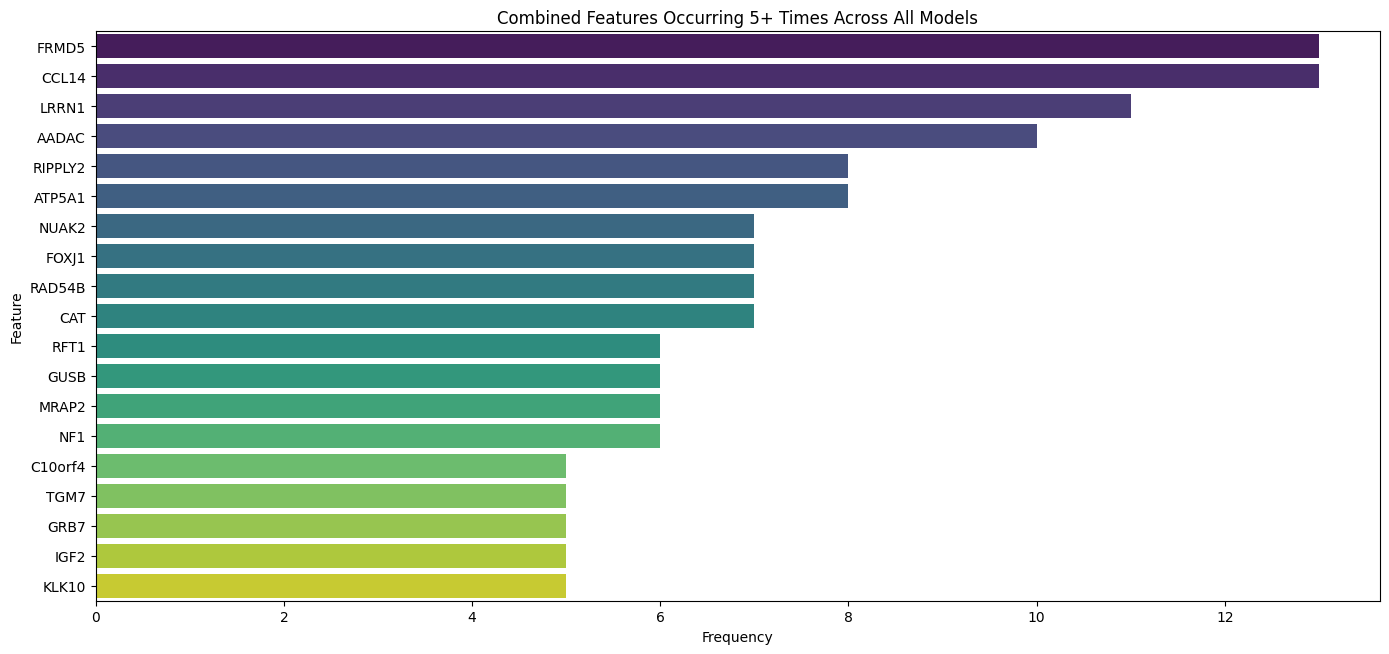

In [13]:
combined_feature_counts = combine_dicts([
    aggregated_explanations["methylation"],
    aggregated_explanations["mrnaseq"],
    aggregated_explanations["cna"]
])

combined_features = plot_features(
    combined_feature_counts,
    min_frequency=5,
    heading="Combined Features Occurring 5+ Times Across All Models",
    display_type="barplot"
)

## 15. Biological interpretation of recurrent multi-omics features

The recurrent features shown above represent genes or genomic regions that repeatedly appeared in the SHAP-based explanations across the CNA, methylation, and mRNA-seq models. In this workflow, the frequency value does **not** mean that a gene is biologically causal. Instead, it shows how often that gene or feature appeared among the strongest local explanation signals across test samples.

Several of the recurrent features connect to ovarian-cancer-relevant biological themes, including DNA repair, homologous recombination, copy-number alteration, oxidative stress response, immune signalling, growth-factor signalling, and tumor progression. High-grade serous ovarian cancer is known to show widespread copy-number alteration, promoter methylation changes, and defects in homologous recombination-related pathways.

| Feature / Gene | Model-level interpretation and ovarian-cancer relevance |
|---|---|
| **FRMD5** | FRMD5 was the most recurrent CNA-linked feature in this run. It is associated with cell adhesion and migration-related biology, so its recurrence may reflect copy-number signals connected to tumor invasion or structural cell-behaviour pathways. Direct ovarian-cancer evidence is limited, so it should be treated as an exploratory model-derived signal. |
| **CCL14** | CCL14 was the dominant mRNA-seq feature. It is a chemokine linked to immune signalling. Prior epithelial ovarian cancer work reported CCL14 as an independent prognostic factor, with higher expression associated with more favourable prognosis. |
| **LRRN1** | LRRN1 appeared strongly in the CNA model. It is involved in cell-surface/neural adhesion-related biology, but direct ovarian-cancer evidence is limited. In this project, it is best described as a recurrent copy-number explanation signal requiring further validation. |
| **AADAC** | AADAC appeared in the combined results and has been studied in ovarian cancer prognosis. Published work has connected an AADAC expression signature with survival outcome and immune-cell infiltration in ovarian cancer. |
| **RIPPLY2** | RIPPLY2 is a developmental transcriptional regulator. Its direct ovarian-cancer role is not well established, but its repeated CNA signal suggests that genomic dosage changes around this region may contain survival-related information in the trained model. |
| **ATP5A1** | ATP5A1 is part of mitochondrial ATP synthase and links to cellular energy metabolism. Since ovarian cancer progression and treatment response can involve metabolic and mitochondrial changes, its recurrence may reflect energy-metabolism-related tumor behaviour. |
| **NUAK2** | NUAK2 has ovarian-cancer relevance. Prior work has reported NUAK2 overexpression in ovarian cancer and suggested links with tumor aggressiveness, migration, and poorer outcomes. |
| **FOXJ1** | FOXJ1 is relevant to ovarian cancer survival interpretation. A high-grade serous ovarian carcinoma study reported that increased FOXJ1 protein expression was associated with improved overall survival. |
| **RAD54B** | RAD54B is directly relevant because it participates in homologous recombination DNA repair. Ovarian cancer treatment biology is strongly linked to homologous recombination deficiency and PARP inhibitor response. RAD54B disruption has been reported to impair HR repair and increase ovarian cancer cell sensitivity to PARP inhibition. |
| **CAT** | CAT encodes catalase, an antioxidant enzyme. Oxidative stress response and antioxidant defence are important in ovarian cancer progression and chemoresistance biology, especially through pathways such as NRF2. |
| **RFT1** | RFT1 is involved in protein glycosylation. Direct ovarian-cancer evidence is limited, but glycosylation changes are broadly relevant to cancer cell signalling, adhesion, and immune interaction. Here, RFT1 should be treated as an exploratory CNA-derived feature. |
| **GUSB** | GUSB is often used as a housekeeping/reference gene in expression studies. It has been evaluated as a stable reference gene in ovarian cancer expression profiling, so its recurrence should be interpreted carefully and not overclaimed as a tumor driver. |
| **MRAP2** | MRAP2 is involved in GPCR-related signalling regulation. Its direct ovarian-cancer role is not well established, but repeated CNA selection may indicate that this genomic region captured survival-associated copy-number structure in the dataset. |
| **NF1** | NF1 is one of the most biologically relevant CNA features because it is a tumor suppressor and regulator of RAS signalling. TCGA's integrated ovarian carcinoma analysis identified NF1 among recurrently altered genes in high-grade serous ovarian cancer. |
| **C10orf4** | C10orf4 appeared as a recurrent methylation-linked feature. Direct ovarian-cancer evidence is limited, so it should be interpreted as a model-discovered methylation signal rather than a confirmed ovarian cancer gene. |
| **TGM7** | TGM7 belongs to the transglutaminase-related family. Direct ovarian-cancer evidence is limited, but transglutaminase-related biology can relate to extracellular matrix, adhesion, and tumor tissue structure. Here, it should remain an exploratory CNA feature. |
| **GRB7** | GRB7 is biologically relevant because it is located near ERBB2/HER2 and is often discussed in relation to ERBB2-driven signalling. ERBB2 amplification occurs in a subset of epithelial ovarian cancers, so this region may capture growth-factor signalling or copy-number effects. |
| **IGF2** | IGF2 is relevant to ovarian cancer because the IGF signalling axis is involved in growth and survival signalling. Prior ovarian cancer work has linked IGF2 overexpression with methylation changes in the IGF2/H19 imprinting region. |
| **KLK10** | KLK10 is a kallikrein-family gene with ovarian-cancer relevance through methylation and biomarker studies. KLK10 methylation has been studied as a prognostic marker in ovarian cancer, making its recurrence in the methylation model biologically plausible. |

### Summary interpretation

Overall, the strongest recurrent signals in this run came from **FRMD5, CCL14, LRRN1, AADAC, RAD54B, FOXJ1, NUAK2, NF1, IGF2, and KLK10**. Among these, **RAD54B, NF1, FOXJ1, CCL14, IGF2, KLK10, AADAC, NUAK2, CAT, and GRB7/ERBB2-related signalling** have the clearest ovarian-cancer or ovarian-cancer-adjacent biological relevance.

The results suggest that the model is not relying only on random isolated features. Several recurrent features align with known ovarian cancer themes, including homologous recombination/DNA repair, immune signalling, copy-number alteration, growth-factor signalling, oxidative stress response, and tumor progression/metastasis-related biology. However, features with limited direct ovarian-cancer evidence should be treated as exploratory candidates that require further validation through external datasets, survival analysis, literature review, or experimental/clinical evidence.

### Reference links used for biological context

- TCGA integrated genomic analysis of ovarian carcinoma: https://pmc.ncbi.nlm.nih.gov/articles/PMC3163504/
- RAD54B and ovarian cancer PARP-inhibitor sensitivity: https://pmc.ncbi.nlm.nih.gov/articles/PMC9463535/
- CCL14 as an epithelial ovarian cancer prognostic biomarker: https://pubmed.ncbi.nlm.nih.gov/32218842/
- FOXJ1 expression and survival in high-grade serous ovarian carcinoma: https://www.nature.com/articles/s41416-022-02014-y
- IGF2 methylation and ovarian cancer: https://pmc.ncbi.nlm.nih.gov/articles/PMC3662894/
- KLK10 methylation and ovarian cancer prognosis: https://pubmed.ncbi.nlm.nih.gov/29690914/
- AADAC expression, prognosis, and immune infiltration in ovarian cancer: https://pubmed.ncbi.nlm.nih.gov/34902961/
- NRF2/oxidative stress response in ovarian cancer: https://pubmed.ncbi.nlm.nih.gov/35453348/
- GUSB as a reference gene in ovarian cancer expression studies: https://pubmed.ncbi.nlm.nih.gov/19622337/
- ERBB2 amplification in ovarian cancer context: https://pmc.ncbi.nlm.nih.gov/articles/PMC6944288/

## 16. Interpretation note

These explainability results should be interpreted as model-level recurrence patterns. They show which genes or features repeatedly influenced the trained models' predictions across test samples. They should not be treated as causal survival biomarkers without further statistical testing, external validation, and biological interpretation.